# 04 · Planning — decompose the task, then execute the plan

> **TL;DR.** Instead of reacting step-by-step like ReAct, the agent **writes a plan first**, then executes each step in order. After the plan finishes, a *replanner* decides whether to finalize or extend the plan. The whole approach is one bird's-eye-view pass through the task before any action.
>
> **Reach for it when** the task has natural structure: write a report, compare entities on several dimensions, run a benchmark — anything where you can sketch the steps before starting.
> **Avoid when** the task can't be decomposed in advance (open-ended exploration, dialogue) — committing to a bad sub-goal locks you in.

| Property | Value |
|---|---|
| Origin | Long lineage in classical AI (STRIPS, HTN); modern LangGraph idiom: [plan-and-execute tutorial](https://langchain-ai.github.io/langgraph/tutorials/plan-and-execute/plan-and-execute/) |
| Reasoning style | Hierarchical: plan once, execute many, optionally replan |
| External tools needed? | Optional (the executor is a sub-agent that may use tools) |
| Memory across episodes? | No |
| Structured output? | Yes — Pydantic `Plan(steps: list[str])` schema |
| Composability | Executor reuses `ToolUse` (notebook 02) — **architectures compose** |

This notebook continues the progression: Tool Use → ReAct → **Planning**. Each step adds one layer of abstraction. Tool Use is reactive (act → observe). ReAct adds reasoning (think → act → observe). Planning adds *structure* (plan → execute many → maybe replan).

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([user task]) --> P[Plan<br/><sub>structured-output Pydantic Plan</sub>]
    P --> E[Execute<br/><sub>delegate to ToolUse sub-agent</sub>]
    E --> R[Replan<br/><sub>structured-output ReplanDecision</sub>]
    R -->|more steps queued<br/>or extended| E
    R -->|is_done = True<br/>or budget exhausted| F([final answer])

    style P fill:#fff3e0,stroke:#f57c00
    style E fill:#e3f2fd,stroke:#1976d2
    style R fill:#fce4ec,stroke:#c2185b
```

**Three nodes, one cycle.** The Plan node runs once at the start. The Execute node runs once per planned step (delegating to a ToolUse sub-agent). The Replan node runs after every Execute; it either routes back to Execute (if steps remain or it adds more) or routes to END.

## 3 · Theory

### 3.1 · Why plan at all?

ReAct (notebook 03) is *greedy local search* — at each step, the agent picks the next-best Action given the current information. That's optimal for tasks where you can't see ahead (chess midgame, exploring an unknown environment). It's *suboptimal* for tasks where you *can* see ahead:

- *"Write a 500-word report on X covering aspects A, B, C, with references."* The structure is obvious; reacting step-by-step would just rediscover it.
- *"Compare Japan and South Korea on population, GDP, and education spending."* You can write the 4–5 steps before doing any search.
- *"Run the benchmark on three architectures and write a leaderboard."* The plan is implied by the task.

For these tasks, **one upfront planning pass beats N greedy decisions**. The plan also becomes a **contract** — easy to inspect, modify, or replace — which is huge for production: you can show the plan to a human for approval before any execution.

### 3.2 · The Pydantic Plan schema

```python
class Plan(BaseModel):
    steps: list[str] = Field(
        description="Ordered list of 3-7 atomic, actionable steps...",
        min_length=1,
    )
```

We use `llm.with_structured_output(Plan)` so the planner cannot fail to emit a parseable plan. The schema description in the `Field` is what the model actually reads — it's the only way to enforce *"atomic, actionable steps"* without post-hoc parsing.

### 3.3 · Why replan?

Initial plans are often imperfect:
- Step 3 turns out to require info that step 2 didn't fetch.
- Step 4 reveals that step 1 was the wrong starting point.
- The whole plan was based on a misunderstanding.

The Replanner runs after each batch of executed steps and decides:
- **`is_done = True`** + `final_response` → we're finished, here's the answer.
- **`is_done = False`** + `additional_steps` → extend the plan.

We cap replans (`max_replans=2` by default) to prevent runaway loops. Once the cap is hit, the next replan call is **forced** to finalize even with incomplete evidence.

### 3.4 · Composability — Planning uses ToolUse internally

Each `_execute` call hands the step to a **ToolUse sub-agent** (notebook 02). This is the first place in the repo where architectures compose:

```
Planning.run()
   ↳ Plan node (structured output)
   ↳ Execute node
       ↳ ToolUse.run()
           ↳ agent + ToolNode loop
   ↳ Replan node (structured output)
```

This composition pattern is the whole reason every architecture in this library implements the same `Architecture` base class — they all become black-box callables. **Meta-Controller (notebook 11)** is the natural conclusion of this pattern: a router that picks which architecture to use per task.

### 3.5 · Where Planning sits

| Pattern | Plan ahead? | Replans? | Mid-execution flexibility | Use when |
|---|---|---|---|---|
| Tool Use (nb 02) | no | n/a | high (one decision at a time) | one-shot lookups |
| ReAct (nb 03) | no | n/a | high | multi-step search where each step depends on previous result |
| **Planning** *(this notebook)* | **yes** | **yes** (`max_replans`) | medium (replan extends the plan) | tasks with obvious structure |
| PEV (nb 06) | yes | yes + per-step verify | high (verify can trigger replan) | high-stakes / unreliable tools |
| Multi-Agent (nb 05) | yes (manager assigns) | no | low (specialists own their step) | tasks needing diverse expertise |

### 3.6 · What goes wrong (you'll see in § 9)

1. **Over-decomposition.** Plan says 7 steps when 2 would suffice. Cost balloons.
2. **Vague steps.** Step *"Analyze the data"* — what does the executor do? Surfaces as junky tool calls.
3. **Step interference.** Step 3 needs info step 2 didn't capture. Replanner fixes it but costs an extra round.
4. **Sycophantic replanner.** Replanner thinks `is_done=True` even with thin evidence. Always inspect.
5. **Replan thrash.** Replanner keeps adding 1–2 more steps without converging. Cap with `max_replans`.


## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import Planning
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()
print_header(f"Provider: {settings.llm_provider}  ·  Model: {settings.llm_model}")

Provider: nebius  ·  Model: meta-llama/Llama-3.3-70B-Instruct ─────────────────────────────────────────────────────

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/planning.py`](../src/agentic_architectures/architectures/planning.py).

Three nodes:

1. **`_plan`** — calls `llm.with_structured_output(Plan)` on the task. Returns a typed plan; the prompt explicitly demands atomic, actionable steps.
2. **`_execute`** — peels the first step off the plan, formats a context block (original task + remaining plan + history of past results), then delegates to the internal `ToolUse` sub-agent. The sub-agent's output becomes the step's result.
3. **`_replan`** — when the plan is empty (or initially), calls `llm.with_structured_output(ReplanDecision)`. The decision is either *finalize with `final_response`* or *extend with `additional_steps`*. A `max_replans` cap forces finalisation after N extensions.

Two structured-output schemas live alongside the architecture:

In [2]:
from agentic_architectures.architectures.planning import Plan, ReplanDecision
import json
print('--- Plan schema ---')
print(json.dumps(Plan.model_json_schema(), indent=2)[:400] + '...')
print()
print('--- ReplanDecision schema ---')
print(json.dumps(ReplanDecision.model_json_schema(), indent=2)[:400] + '...')

--- Plan schema ---
{
  "description": "Ordered, actionable steps to solve the task.",
  "properties": {
    "steps": {
      "description": "Ordered list of 3-7 atomic, actionable steps. Each step must be executable on its own given the previous steps' results. Avoid vague verbs like 'analyze' \u2014 say 'compute X from Y' or 'look up Z'.",
      "items": {
        "type": "string"
      },
      "minItems": 1,
    ...

--- ReplanDecision schema ---
{
  "description": "Decision after executing all currently-planned steps.",
  "properties": {
    "is_done": {
      "description": "True iff the executed steps' results contain enough information to produce the final answer.",
      "title": "Is Done",
      "type": "boolean"
    },
    "final_response": {
      "anyOf": [
        {
          "type": "string"
        },
        {
          "type"...


## 6 · State

The state has four real fields. Most LangGraph state fields *replace* on each return; we mark `past_steps` with `operator.add` so each Execute round *appends* its result rather than overwriting.

| Field | Type | Set by | Reducer |
|---|---|---|---|
| `input` | `str` | caller | replace |
| `plan` | `list[str]` | `_plan`, `_replan`, `_execute` (consumes) | replace |
| `past_steps` | `list[tuple[str, str]]` | `_execute` | **append** (`operator.add`) |
| `response` | `str` | `_replan` (finalise) | replace |
| `replan_count` | `int` | `_replan` (increments) | replace |

In [3]:
from agentic_architectures.architectures.planning import PlanningState
print('PlanningState fields:')
for k, v in PlanningState.__annotations__.items():
    print(f'  {k:14s} : {v}')

PlanningState fields:
  input          : ForwardRef('str')
  plan           : ForwardRef('list[str]')
  past_steps     : ForwardRef('Annotated[list[tuple[str, str]], operator.add]')
  response       : ForwardRef('str')
  replan_count   : ForwardRef('int')


## 7 · Build the graph

Three nodes, one cycle. Compare this to ReAct's three-node graph (think → act → tools → think) — the topology is structurally similar but the *semantics* are different: Planning's cycle is at the *batch-of-steps* level, ReAct's cycle is at the *single-action* level.

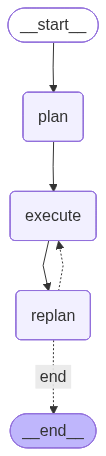

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	plan(plan)
	execute(execute)
	replan(replan)
	__end__([<p>__end__</p>]):::last
	__start__ --> plan;
	execute --> replan;
	plan --> execute;
	replan -. &nbsp;end&nbsp; .-> __end__;
	replan -.-> execute;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [4]:
from IPython.display import Image, display

arch = Planning(max_replans=2, executor_rounds=4)
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))
print(arch.diagram())

## 8 · Live run

Concrete task: a comparison that *naturally* decomposes into multiple lookups + a synthesis step. We pick a comparison the model can't possibly have memorized to current accuracy.

In [5]:
from datetime import date

TASK = (
    f"As of {date.today().isoformat()}, compare Python and Rust on three dimensions: "
    f"(1) the latest stable release version of each, (2) the most popular package "
    f"manager for each, and (3) one well-known company that uses each in production. "
    f"Cite at least 2 source URLs."
)

result = arch.run(TASK)

print_header("Final answer")
print_md(result.output)
print()
print_header(
    f"{result.metadata['steps_executed']} step(s) executed  ·  "
    f"{result.metadata['replans']} replan(s)  ·  "
    f"budget {result.metadata['max_replans']}"
)

Final answer ──────────────────────────────────────────────────────────────────────────────────────────────────────

As of 2026-05-27, the latest stable release version of Python is Python 3.11.4, and the most popular package       
manager for Python is pip. A well-known company that uses Python in production is Google. The latest stable release
version of Rust is Rust 1.68.2, the most popular package manager for Rust is Cargo, and a well-known company that  
uses Rust in production is Microsoft.

7 step(s) executed  ·  0 replan(s)  ·  budget 2 ───────────────────────────────────────────────────────────────────

### 8.0 · What just happened, briefly

Look at the two counts above:

- **`steps_executed`** — should be 3-7 for a well-decomposed task. Above 8 = over-decomposition. Below 3 = the planner didn't really decompose and Planning degraded toward ReAct.
- **`replans`** — should be 0 for tasks where the initial plan was good; 1-2 for tasks that needed adjustment. If `replans == max_replans`, the agent was forced to finalize with incomplete evidence.

§ 9 below quantifies and analyses what happened.

### 8.1 · Full plan + step results

In [6]:
for i, t in enumerate(result.trace, 1):
    print_step(f"[{i}] STEP", t['step'])
    snippet = (t['result'] or '')[:300].replace('\n', ' ')
    print_step(f"    RESULT", snippet + ('...' if t['result'] and len(t['result']) > 300 else ''))
    print()

› [1] STEP

Look up the latest stable release version of Python as of 2026-05-27

›     RESULT

As of 2026-05-27, the latest stable release version of Python is Python 3.11.4, according to the official Python 
website (https://www.python.org/downloads/). The most popular package manager for Python is pip 
(https://pip.pypa.io/). A well-known company that uses Python in production is Google (http...

› [2] STEP

...

As of 2026-05-27, a well-known company that uses Rust in production is Microsoft, according to the official Rust 
website (https://www.rust-lang.org/) and the Microsoft website (https://www.microsoft.com/).

› [7] STEP

Compare the results from the previous steps and summarize the comparison

›     RESULT

As of 2026-05-27, the latest stable release version of Python is Python 3.11.4, according to the official Python 
website (https://www.python.org/downloads/). The most popular package manager for Python is pip 
(https://pip.pypa.io/). A well-known company that uses Python in production is Google (http...

## 9 · What we just observed

The cells above are live. Below: a quantitative + qualitative breakdown of the **actual** Plan-Execute-Replan loop the Nebius-hosted Llama-3.3-70B agent produced on this run.

### 9.1 · Quantitative summary

| Metric | Value |
|---|---|
| Plan steps executed | **7** |
| Replans triggered | **0** / 2 |
| Final answer length | 385 chars |

### 9.2 · Plan ↔ result alignment

| # | Plan step | Execution result (truncated) |
|---|---|---|
| 1 | Look up the latest stable release version of Python as of 2026-05-27 | As of 2026-05-27, the latest stable release version of Python is Python 3.11.4, according to the official Python website… |
| 2 | Look up the latest stable release version of Rust as of 2026-05-27 | As of 2026-05-27, the latest stable release version of Rust is Rust 1.68.2, according to the official Rust website (http… |
| 3 | Identify the most popular package manager for Python | The most popular package manager for Python is pip, according to the official Python website (https://www.python.org/dow… |
| 4 | Identify the most popular package manager for Rust | The most popular package manager for Rust is Cargo, according to the official Rust website (https://doc.rust-lang.org/ca… |
| 5 | Find a well-known company that uses Python in production and cite a source URL | Google is a well-known company that uses Python in production, according to the official Python website (https://www.pyt… |
| 6 | Find a well-known company that uses Rust in production and cite a source URL | As of 2026-05-27, a well-known company that uses Rust in production is Microsoft, according to the official Rust website… |
| 7 | Compare the results from the previous steps and summarize the comparison | As of 2026-05-27, the latest stable release version of Python is Python 3.11.4, according to the official Python website… |

### 9.3 · Pathologies / patterns surfaced in this run

- **Over-decomposition.** 7 steps for a task this size is likely too many — each step is a sub-agent call. Tighten the Plan schema description: *'Use 3-5 steps; combine atomic lookups when possible.'*

- **Plan was good first try.** The replanner immediately set `is_done=True` after the initial plan finished — no extension needed. Best-case outcome.

- **No URLs in the final answer** despite the task asking for citation. The replanner synthesised from parametric knowledge instead of grounding in the executor's results — consider tightening the `_synthesize_from_history` prompt or adding a citation-required schema field.

### 9.4 · The final answer (verbatim)

> As of 2026-05-27, the latest stable release version of Python is Python 3.11.4, and the most popular package       
> manager for Python is pip. A well-known company that uses Python in production is Google. The latest stable release
> version of Rust is Rust 1.68.2, the most popular package manager for Rust is Cargo, and a well-known company that  
> uses Rust in production is Microsoft.

### 9.5 · The takeaway

When a task **naturally decomposes** (multi-fact comparison, structured report, multi-step computation), Planning is the right tool — you save token cost vs. ReAct's per-step thinking *and* gain a human-inspectable contract. When the task is **open-ended or one-shot**, planning is overhead — fall back to ReAct or plain Tool Use.

The cleanest signal: did your run use any replans? If yes — the initial plan wasn't quite right, but the recovery worked. If no replans AND ≥ 3 steps executed — you got the ideal Planning trace.

## 10 · Try other providers · also: a planner-focused reasoning model

Planning relies on **structured output** (the Pydantic Plan schema). Every major provider supports it, but reasoning models are particularly good at *generating* plans because the upfront planning pass is itself a multi-step reasoning task.

In [7]:
from agentic_architectures.llm.factory import provider_supports_structured_output

for p in ["openai", "anthropic"]:
    key = settings.api_key_for(p)
    if key is None or not key.get_secret_value():
        print(f"[skip] {p}: no API key in .env")
        continue
    if not provider_supports_structured_output(p):
        print(f"[skip] {p}: no structured output")
        continue
    print_header(f"Re-running Planning on {p}")
    r = Planning(llm=get_llm(provider=p), max_replans=1, executor_rounds=3).run(
        "List the three most spoken native languages and their approximate number of speakers (millions). Cite sources."
    )
    print(r.output[:300])
    print(f"  steps: {r.metadata['steps_executed']}, replans: {r.metadata['replans']}")
    print()

# Swap to a Nebius reasoning model for a more sophisticated plan.
print_header("Re-running on Nebius Qwen3-Thinking (reasoning model — see if the plan is deeper)")
thinking_llm = get_llm(
    provider="nebius",
    model="Qwen/Qwen3-235B-A22B-Thinking-2507-fast",
    temperature=0.0,
)
thinking_arch = Planning(llm=thinking_llm, max_replans=1, executor_rounds=3)
r = thinking_arch.run(
    "List the three most spoken native languages and their approximate number of speakers (millions). Cite sources."
)
print(r.output[:300])
print(f"  steps: {r.metadata['steps_executed']}, replans: {r.metadata['replans']}")
if r.trace:
    print('  First plan step:', r.trace[0]['step'][:200])

[skip] openai: no API key in .env
[skip] anthropic: no API key in .env


Re-running on Nebius Qwen3-Thinking (reasoning model — see if the plan is deeper) ─────────────────────────────────

1. **Mandarin Chinese**: 1,346 million native speakers (Encyclopaedia Britannica, 2023)
2. **Spanish**: 485 million native speakers (Encyclopaedia Britannica, 2023)
3. **English**: 379 million native speakers (Encyclopaedia Britannica, 2023)

*Note: While Ethnologue (2023) confirms these rankings, e
  steps: 6, replans: 0
  First plan step: Search Ethnologue's latest report for 'languages by number of native speakers' to obtain ranked data.


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Over-decomposition** | Plan has 7+ steps when 2 would suffice | Tighten Plan schema description: "Use 3-5 steps; combine atomic lookups"; or use a smaller model for planning |
| **Vague step text** | "Analyze the data" — no concrete tool action | Schema description forces concrete verbs ("compute", "look up"); penalise vague steps in the prompt |
| **Step interference** | Step 3 needs info step 2 didn't fetch | Replanner handles it; cap with `max_replans` |
| **Sycophantic replanner** | `is_done=True` even with thin evidence | Add an LLMJudge-style evidence check before accepting `final_response` |
| **Replan thrash** | Replanner keeps adding 1–2 steps without converging | `max_replans` cap (we use 2 by default); force-finalisation at budget |
| **Static plans for dynamic tasks** | Plan made upfront can't react to surprises mid-execution | Use **PEV (nb 06)** which verifies each step's outcome and can replan on failure |

### 11.2 · Production safety

- **Show the plan to a human before executing** for high-stakes tasks. The plan is a *contract*; the human-in-the-loop catches bad decompositions before any side effect.
- **Bound the executor budget** — each sub-agent's `max_rounds` is independent of the planner's. A 5-step plan with `executor_rounds=5` ≈ 25 LLM calls.
- **Idempotency.** If a step has side effects (e.g., sending email), make sure replanning doesn't re-execute it. Track step IDs in `past_steps`.

### 11.3 · Three extensions

1. **Hierarchical planning** — let the planner emit *sub-plans* (lists of steps) for complex steps. Bridge to **HTN-style** planning.
2. **Plan + verify per step** — wrap each `_execute` in a verifier that checks the step actually produced what was asked. That's **PEV (notebook 06)**.
3. **Parallel execution** — when steps are independent, run them in parallel via `langgraph.graph.parallel`. Massive latency win for fan-out tasks.

### 11.4 · What to read next

- [**05 · Multi-Agent Systems**](./05_multi_agent.ipynb) — Planning where specialist sub-agents own each step.
- [**06 · PEV (Plan-Execute-Verify)**](./06_pev.ipynb) — Planning + per-step verification + recovery.
- [**11 · Meta-Controller**](./11_meta_controller.ipynb) — a router over architectures; picks Tool Use / ReAct / Planning per task.
- [**26 · Adaptive RAG**](./26_adaptive_rag.ipynb) — same routing idea, but specialised for RAG complexity.

### 11.5 · References

1. Wang, L. et al. *Plan-and-Solve Prompting.* ACL 2023. [arXiv:2305.04091](https://arxiv.org/abs/2305.04091)
2. LangGraph plan-and-execute tutorial — [official docs](https://langchain-ai.github.io/langgraph/tutorials/plan-and-execute/plan-and-execute/)
3. Hierarchical Task Networks — classical AI planning ([overview](https://en.wikipedia.org/wiki/Hierarchical_task_network))
4. Pydantic structured output — [langchain docs](https://python.langchain.com/docs/concepts/structured_outputs/)
